In [58]:
import numpy as np
import matplotlib.pyplot as plt

## Ordinary Least Squares (OLS) Regression

| Code | Description |
| --- | --- |
| `X = np.random.randn(10, 1)` | Create a 10-by-1 array of random numbers called `X` |
| `np.ones((10, 1))` | Create 10-by-1 array of ones |
| `np.hstack((np.ones(10, 1), X))` | Stack a column of ones to the left side of `X`|
| `X.T` | Transpose the matrix `X` |
| `X.T @ X` | Multiply the matrix `X` with it's transpose |
| `np.linalg.solve(X.T @ X, X.T @ y)` | Solve the equation $\beta = (X^T X)^{-1} X^T y$ |
| `plt.plot(x, y)` | Create a line plot for `x` and `y` |
| `plt.scatter(x, y)` | Create a scatter plot for `x` and `y` |

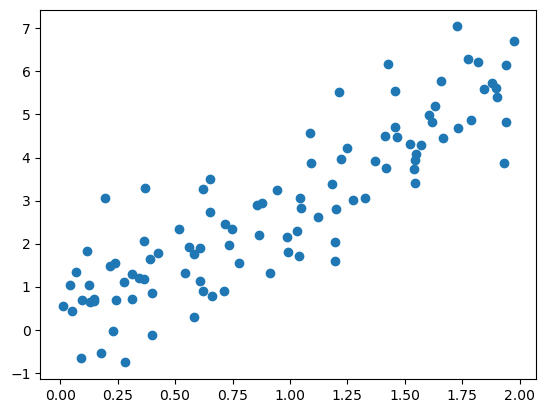

In [59]:
np.random.seed(42)
X = 2 * np.random.rand(100 , 1)
y = 3 * X + np.random.randn(100 , 1)
plt.scatter(X, y)

$$\beta = (X^T X)^{-1} X^T y$$

In [60]:
beta = np.linalg.solve(X.T @ X, X.T @ y)
beta

array([[2.93392781]])

In [61]:
X.shape

(100, 1)

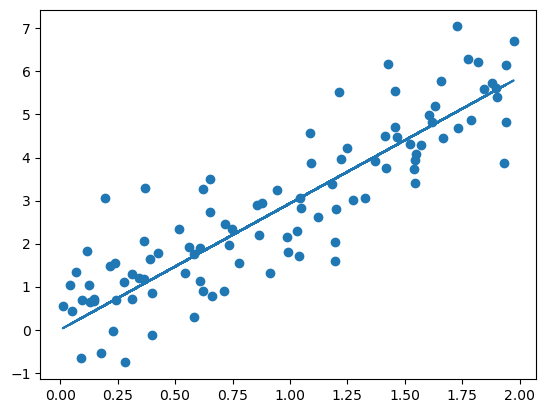

In [62]:
plt.scatter(X, y)
plt.plot(X, X @ beta)

With intercept

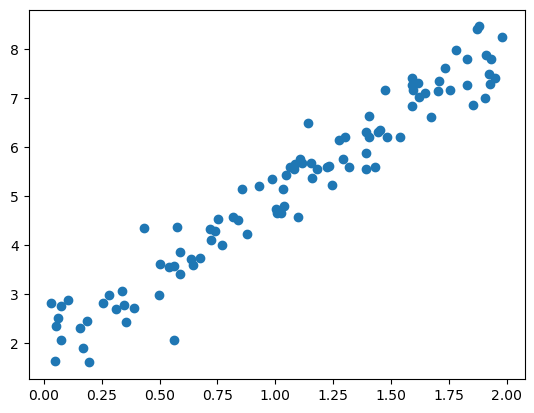

In [63]:

X = 2 * np.random.rand(100 , 1)
y = 2+ 3 * X + np.random.randn(100 , 1) * 0.5
plt.scatter(X, y)

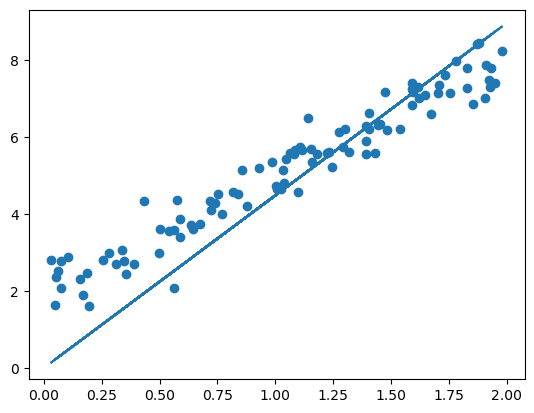

In [64]:
beta = np.linalg.solve(X.T @ X, X.T @ y)
plt.scatter(X, y)
plt.plot(X, X @ beta)

In [65]:
X = np.hstack((np.ones((100, 1)), X))

In [66]:
beta = np.linalg.solve(X.T @ X, X.T @ y)
beta

array([[1.93250526],
       [3.06958089]])

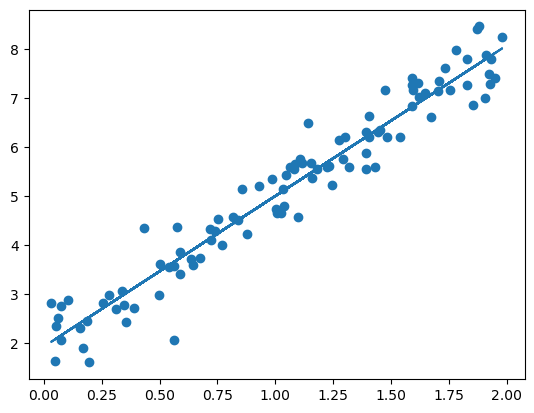

In [67]:
plt.scatter(X[:, 1:], y)
plt.plot(X[:,1:], X @ beta)

## Ridge Regularization

In [ ]:
X = np.random.randn(100, 5)
X = np.hstack((np.ones((100, 1)), X))
y = 2 + 3*X[:,1] - 1.5*X[:,2] + 0.8*X[:,3] + 0*X[:,4] + -0.5*X[:,5] + np.random.randn(100)
y = y[:, np.newaxis]

X.shape, y.shape

In [ ]:
n_train = 15
n_test = X.shape[0]-n_train

X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

In [ ]:
beta = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)
beta

In [ ]:
y_train_pred = X_train @ beta
np.sqrt(np.mean((y_train-y_train_pred)**2))

In [ ]:
y_test_pred = X_test @ beta
np.sqrt(np.mean((y_test-y_test_pred)**2))

$$\beta = (X^T X + \lambda I)^{-1} X^T y$$

minimizes

$$\min_\beta \left( ||y - X\beta||^2 + \lambda ||\beta||^2 \right)$$

In [ ]:
I = np.eye(X.shape[1])
I[0, 0] = 0
lam = 0.2
beta = np.linalg.solve(X_train.T @ X_train + lam * I, X_train.T @ y_train)
beta

In [ ]:
mse_test = []
mse_train = []
lambdas = np.linspace(0.1, 2, 20)
for lam in lambdas:
    beta = np.linalg.solve(X_train.T @ X_train + lam * I, X_train.T @ y_train)
    y_test_pred = X_test @ beta
    mse_test.append(np.sqrt(np.mean((y_test-y_test_pred)**2)))
    y_train_pred = X_train @ beta
    mse_train.append(np.sqrt(np.mean((y_train-y_train_pred)**2)))

fig, ax = plt.subplots(1,2, figsize=(8,3))
ax[0].plot(lambdas, mse_train)
ax[0].set(xlabel="$\lambda$", ylabel="MSE", title="Training Data")
ax[1].plot(lambdas, mse_test)
ax[1].set(xlabel="$\lambda$", title="Test Data")

## Multiple Features

| Code | Description |
| --- | --- |
| `X = np.random.randn(10, 3)` | Create a 10-by-3 array of random numbers called `X` |
| `np.ones((10, 1))` | Create 10-by-1 array of ones |
| `np.hstack((np.ones(10, 1), X))` | Stack a column of ones to the left side of `X`|
| `X.T` | Transpose the matrix `X` |
| `X.T @ X` | Multiply the matrix `X` with it's transpose |
| `np.linalg.solve(X.T @ X, X.T @ y)` | Solve the equation $\beta = (X^T X)^{-1} X^T y$ |
| `plt.plot(x, y)` | Create a line plot for `x` and `y` |
| `plt.scatter(x, y)` | Create a scatter plot for `x` and `y` |

[Text(0.5, 0, 'X3')]

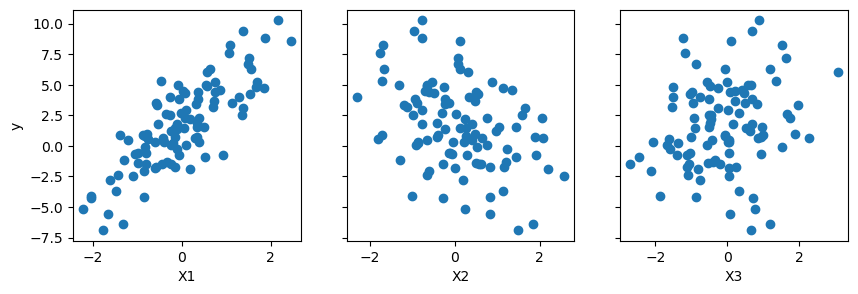

In [68]:
X = np.random.randn(100, 3)
X = np.hstack((np.ones((100, 1)), X))
y = 2 + 3*X[:,1] - 1.5*X[:,2] + 0.8*X[:,3] + np.random.randn(100)
y = y[:, np.newaxis]

fig, ax = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
ax[0].scatter(X[:,1], y)
ax[0].set(xlabel="X1", ylabel="y")
ax[1].scatter(X[:,2], y)
ax[1].set(xlabel="X2")
ax[2].scatter(X[:,3], y)
ax[2].set(xlabel="X3")

In [69]:
beta = np.linalg.solve(X.T @ X, X.T @ y)
beta


array([[ 1.89610131],
       [ 3.01624822],
       [-1.53642334],
       [ 0.89456357]])

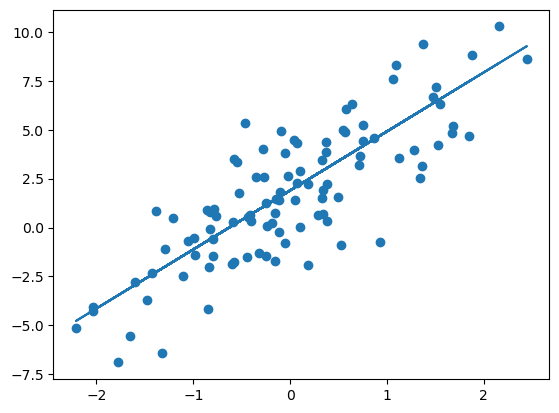

In [70]:
feature = 1
plt.scatter(X[:,feature], y)
plt.plot(X[:, feature], X[:, [0, feature]] @ beta[[0, feature]])


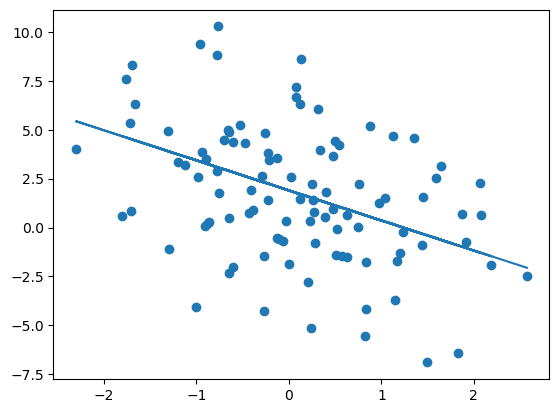

In [71]:
feature = 2
plt.scatter(X[:,feature], y)
plt.plot(X[:, feature], X[:, [0, feature]] @ beta[[0, feature]])

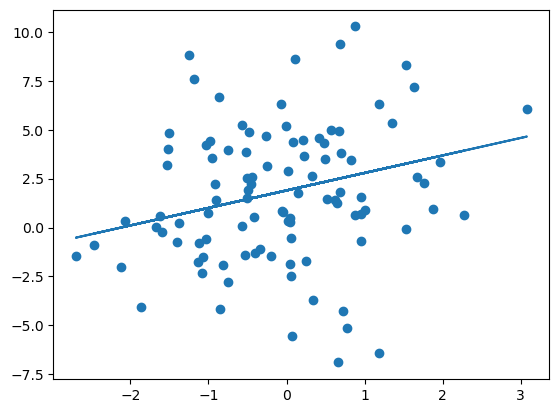

In [72]:
feature = 3
plt.scatter(X[:,feature], y)
plt.plot(X[:, feature], X[:, [0, feature]] @ beta[[0, feature]])

## Colinearity

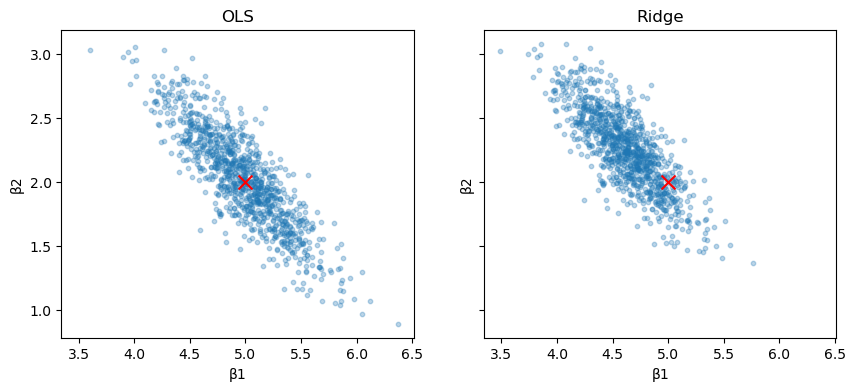

In [193]:
n = 20  # number of samples
r = 0.8 # correlation of features
beta1 = 5
beta2 = 2

x1 = np.random.randn(n)
x2 = r * x1 + np.sqrt(1 - r**2) * np.random.randn(n)
X = np.column_stack([np.ones(n), x1, x2])
I = np.eye(3)
I[0,0] = 0
beta_ols = []
beta_ridge = []
for _ in range(1000):
    y = beta1 * x1 + beta2 * x2 + np.random.randn(n)
    beta_ols.append(np.linalg.solve(X.T @ X, X.T @ y))
    beta_ridge.append(np.linalg.solve(X.T @ X + 1.0 * I, X.T @ y))
beta_ols = np.array(beta_ols).squeeze()  # Shape: (1000, 3)
beta_ridge = np.array(beta_ridge).squeeze()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
axes[0].scatter(beta_ols[:, 1], beta_ols[:, 2], alpha=0.3, s=10)
axes[0].scatter(beta1, beta2, color='red', s=100, marker='x', label='True')
axes[0].set(xlabel='β1', ylabel='β2', title='OLS')
axes[1].scatter(beta_ridge[:, 1], beta_ridge[:, 2], alpha=0.3, s=10)
axes[1].scatter(beta1, beta2, color='red', s=100, marker='x', label='True')
axes[1].set(xlabel='β1', ylabel='β2', title='Ridge');
